In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease/heart.csv


In [2]:
df = pd.read_csv('/kaggle/input/heart-disease/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df = df[df['ca'] != 4]
df = df[df['thal'] != 0]

In [5]:
df['target'].value_counts()

target
1    160
0    136
Name: count, dtype: int64

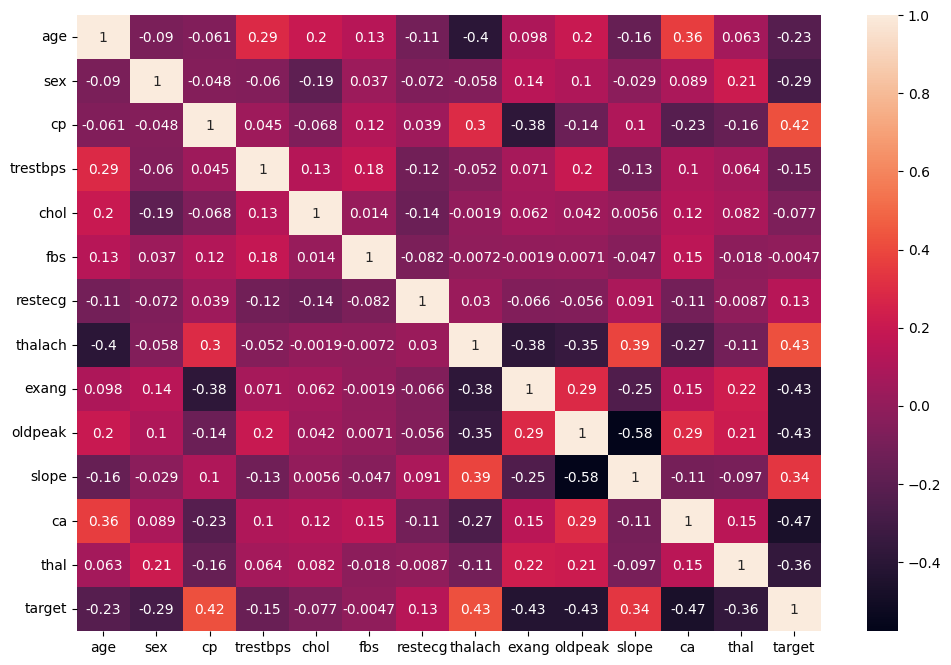

In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize = (12 , 8))
sns.heatmap(df.corr() , annot = True)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'target' , axis = 1)
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 15)


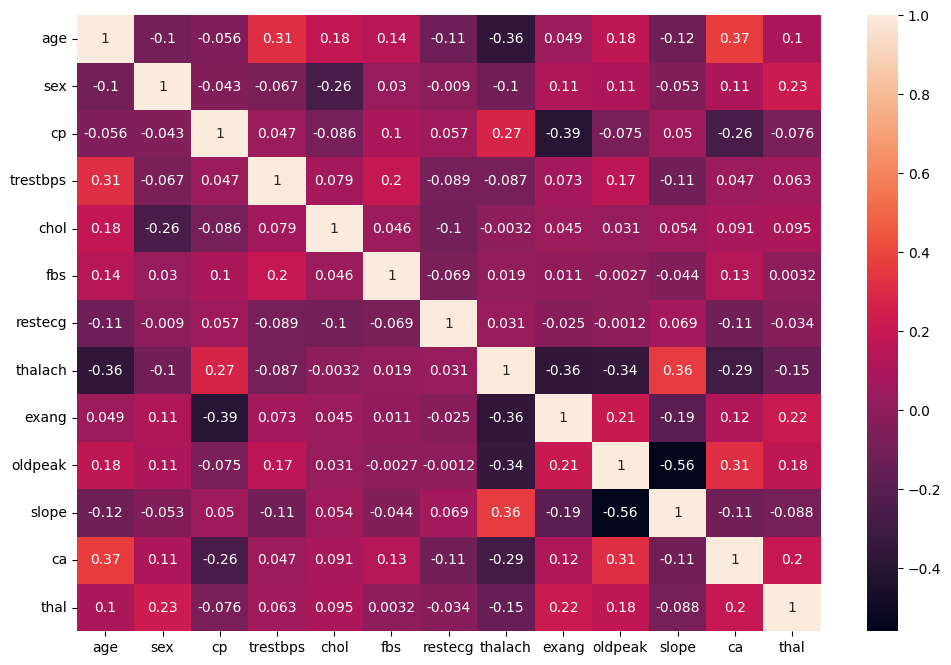

In [8]:

plt.figure(figsize = (12 , 8))
sns.heatmap(X_train.corr() , annot = True)
plt.show()

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gbc = GradientBoostingClassifier()
gbc.fit(X_train , y_train)
y_pred = gbc.predict(X_test)


In [10]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print('Accuracy Score : ' , accuracy_score(y_test , y_pred))
print('Classification Report : \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))


Accuracy Score :  0.8666666666666667
Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.92      0.86        26
           1       0.93      0.82      0.87        34

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.88      0.87      0.87        60

Confusion Matrix : 
 [[24  2]
 [ 6 28]]


In [11]:
params = {
    'max_depth' : [3 ,4 , 5],
    'n_estimators' : [100 , 150 , 200 , 250],
    'loss' : ['log_loss' , 'exponential'],
    'learning_rate' : [0.01 , 0.1 , 0.25 ,0.5 ,1 ]
    
}

In [12]:
grid = GridSearchCV(estimator = GradientBoostingClassifier() , param_grid = params , n_jobs = -1 , cv = 5 , scoring = 'accuracy')
grid.fit(X_train , y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.25, 0.5, 1],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 150, 200, 250]},
             scoring='accuracy')

In [13]:
y_pred = grid.predict(X_test)

print('Accuracy Score : ' , accuracy_score(y_test , y_pred))
print('Classification Report : \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))


Accuracy Score :  0.8833333333333333
Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.92      0.87        26
           1       0.94      0.85      0.89        34

    accuracy                           0.88        60
   macro avg       0.88      0.89      0.88        60
weighted avg       0.89      0.88      0.88        60

Confusion Matrix : 
 [[24  2]
 [ 5 29]]
